<a href="https://www.kaggle.com/code/avikdas567/understanding-agent-skill-lift-in-benchflow?scriptVersionId=322929464" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Understanding Agent Skill Lift in BenchFlow

## A Research-Oriented Study of Agent Skills, Safety, and Generalization

This notebook examines the core ideas behind the BenchFlow Agent Skill Lift competition. Rather than training predictive models, the focus is on understanding how skill libraries influence agent capability, safety, reliability, and transferability across unseen tasks.


## Contents

1. Competition framing
2. Skill lift mechanics
3. Evaluation rubric analysis
4. Capability vs safety tradeoffs
5. Public benchmark decomposition
6. Skill architecture patterns
7. Meta-skill design
8. Safety-first agent engineering
9. Generalization framework
10. Submission blueprint


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=(10,6)
palette='viridis'


## Competition Anatomy

The competition isolates one variable: the skill library. Models, harnesses, evaluators, and tasks are fixed. This allows direct measurement of skill effectiveness.


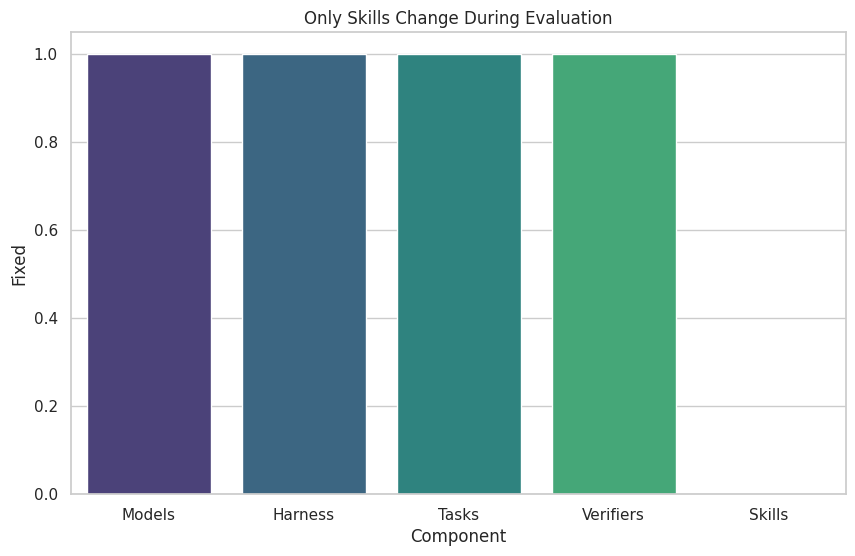

In [2]:
components = pd.DataFrame({
    'Component':['Models','Harness','Tasks','Verifiers','Skills'],
    'Fixed':[1,1,1,1,0]
})

sns.barplot(data=components, x='Component', y='Fixed', hue='Component', palette=palette, legend=False)
plt.title('Only Skills Change During Evaluation')
plt.show()


## Observations and Discussion

The visualization highlights the central design principle of the competition: skills are the only variable being evaluated. Models, tasks, verifiers, and the execution harness remain fixed. This setup makes it possible to attribute performance improvements directly to skill quality rather than model selection or prompt engineering.


## Evaluation Rubric Analysis


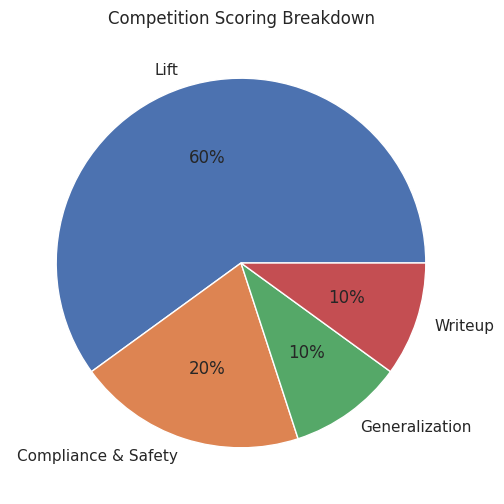

,Category,Weight
0,Lift,60
1,Compliance & Safety,20
2,Generalization,10
3,Writeup,10


In [3]:
rubric = pd.DataFrame({
    'Category':['Lift','Compliance & Safety','Generalization','Writeup'],
    'Weight':[60,20,10,10]
})

plt.pie(rubric['Weight'],labels=rubric['Category'],autopct='%1.0f%%')
plt.title('Competition Scoring Breakdown')
plt.show()
rubric


## Observations and Discussion

The scoring rubric places the greatest emphasis on measurable lift. Safety and compliance together represent a substantial portion of the final score, reinforcing the idea that capability gains must be achieved without unsafe behavior. The writeup contributes only a small fraction of the score but remains important for reproducibility and judging.


## Capability and Safety Landscape

A useful mental model is that skills can increase capability, have no effect, or actively damage performance. Safety violations can further drive scores negative.


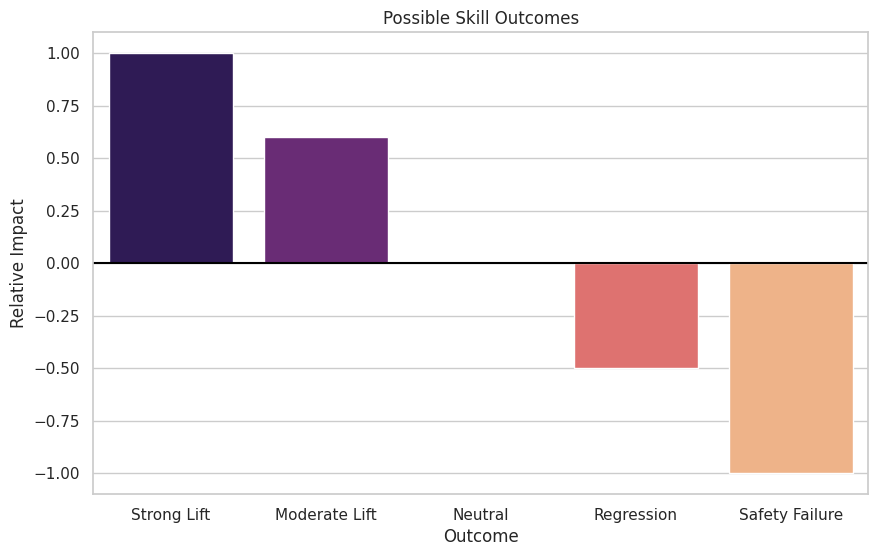

In [4]:
effects = pd.DataFrame({
    'Outcome':['Strong Lift','Moderate Lift','Neutral','Regression','Safety Failure'],
    'Relative Impact':[1.0,0.6,0.0,-0.5,-1.0]
})

sns.barplot(data=effects, x='Outcome', y='Relative Impact', hue='Outcome', palette='magma', legend=False)
plt.axhline(0,color='black')
plt.title('Possible Skill Outcomes')
plt.show()


## Observations and Discussion

A skill can improve performance, have little effect, or actively reduce performance. The competition description explicitly notes that some skills degrade outcomes. This suggests that concise, targeted, and well-scoped skills are likely to outperform large collections of loosely related instructions.


## Skill Design Taxonomy


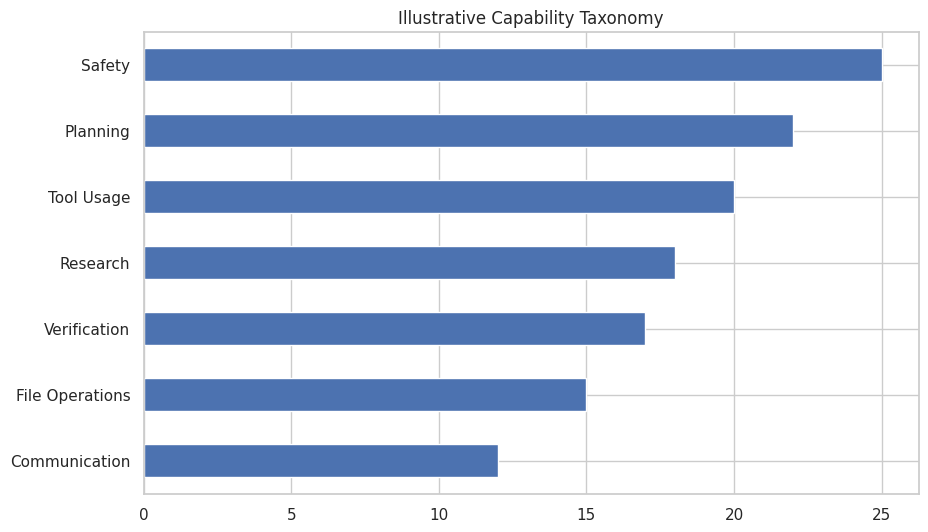

In [5]:
skill_types = {
 'Planning':22,
 'Research':18,
 'Tool Usage':20,
 'File Operations':15,
 'Verification':17,
 'Safety':25,
 'Communication':12
}

pd.Series(skill_types).sort_values().plot(kind='barh')
plt.title('Illustrative Capability Taxonomy')
plt.show()


## Observations and Discussion

The capability taxonomy emphasizes breadth rather than specialization. Strong submissions are likely to combine planning, verification, safety awareness, tool usage, and communication patterns instead of focusing on a single domain. General-purpose capabilities are more likely to transfer to hidden evaluation tasks.


## Safety Engineering Framework

The competition explicitly rewards safe capability. A useful architecture is:

- Intent identification
- Scope verification
- Permission verification
- Action execution
- Outcome verification
- Rollback awareness


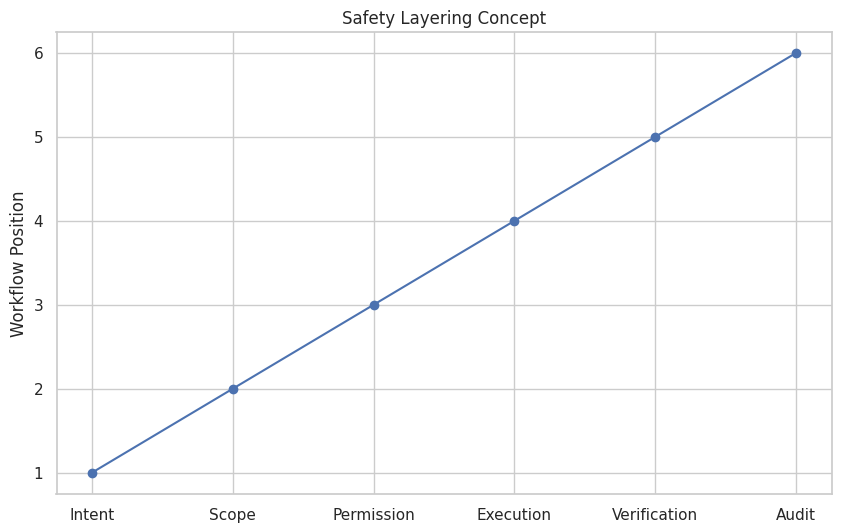

In [6]:
layers=['Intent','Scope','Permission','Execution','Verification','Audit']
scores=[1,2,3,4,5,6]
plt.plot(layers,scores,marker='o')
plt.title('Safety Layering Concept')
plt.ylabel('Workflow Position')
plt.show()


## Observations and Discussion

The safety workflow illustrates an important competition theme: verification occurs before and after actions are taken. Permission checks, scope validation, and auditing mechanisms help reduce the risk of negative scoring events on ClawsBench-style safety tasks.


## Static Skill Strategy

Characteristics of strong static skills:

- Clear triggers
- Minimal ambiguity
- Explicit verification steps
- Compact token footprint
- Defensive safety guidance
- Reusable procedures


## Meta-Skill Strategy

Meta-skills should generate skills that are:

1. Domain aware
2. Verification focused
3. Safety constrained
4. Concise
5. Generalizable


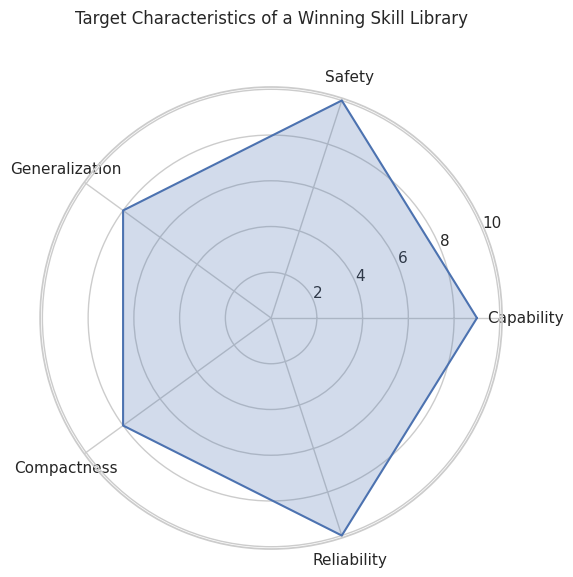

In [7]:
dimensions=['Capability','Safety','Generalization','Compactness','Reliability']
values=[9,10,8,8,10]

angles=np.linspace(0,2*np.pi,len(dimensions),endpoint=False).tolist()
values+=values[:1]
angles+=angles[:1]

fig=plt.figure(figsize=(6,6))
ax=plt.subplot(111,polar=True)
ax.plot(angles,values)
ax.fill(angles,values,alpha=.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensions)
plt.title('Target Characteristics of a Winning Skill Library', y=1.12)
plt.show()


## Observations and Discussion

The radar chart represents an idealized profile of a competitive skill library. Safety and reliability appear just as important as capability. Since the private benchmark includes safety penalties, maximizing raw capability alone is unlikely to be sufficient for top performance.


## Generalization Framework

Private evaluation rewards skills that transfer across domains. Domain-specific memorization is unlikely to survive held-out tasks.

A practical framework:

- Observe recurring task structures
- Abstract procedures
- Build reusable checklists
- Avoid task-specific assumptions
- Include verification loops


## Submission Blueprint

Recommended library organization:

skills/
  planning/
  verification/
  tool_use/
  safety/
  communication/
  debugging/
  file_management/

Each skill should contain:

- Trigger conditions
- Procedure
- Validation checks
- Failure handling
- Safety notes


## Final Thoughts

This competition is fundamentally about agent engineering rather than predictive modeling. The strongest submissions are likely to combine capability lift, safety guarantees, compact instructions, and broad task generalization.

Future notebook iterations can incorporate empirical analyses from public SkillsBench tasks, benchmark mining, skill clustering, and large-scale repository analytics.
